# ERCOT - Actual Load EDA

**Raw source:**   
**Data source:** `data/raw/ercot/load_fzn_20210101_20260527.parquet` 

**Outputs:** `data/01_processed/load/..`
- 'load_by_LZ_20201231_20260526.parquet'
- 'total_load_20201231_20260526.csv'

## 1. Imports & paths

In [32]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

PROJECT_ROOT = Path('../..').resolve()
PARQUET_PATH = PROJECT_ROOT / '01_data' / '1.2_raw_api' / 'load_fzn_20201231_20260526.parquet'
OUT_DIR      = PROJECT_ROOT / '01_data' / '2_cleaned' / 'load'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Parquet : {PARQUET_PATH}')
print(f'Output  : {OUT_DIR}')

Parquet : /Users/zyliazhang/Git/RESEARCH-PJM-ERCOT-Price-Volatility/data/parquet/ercot/load_fzn_20201231_20260526.parquet
Output  : /Users/zyliazhang/Git/RESEARCH-PJM-ERCOT-Price-Volatility/data/02_processed/load


## 2. Load & inspect with DuckDB

In [33]:
con = duckdb.connect()
# validate time range and column names
time_range = con.execute(f"""
    SELECT MIN(operatingDay) AS min_date, MAX(operatingDay) AS max_date
    FROM read_parquet('{PARQUET_PATH}')
""").fetchone()
print('=== Time Range ===')
print(f'{time_range[0]} to {time_range[1]}')

column_schema = con.execute(f"""
    DESCRIBE SELECT * FROM read_parquet('{PARQUET_PATH}')
""").df()
print('\n=== Schema ===')
print(column_schema.to_string(index=False))

row_count = con.execute(f"""
    SELECT COUNT(*) FROM read_parquet('{PARQUET_PATH}')
""").fetchone()[0]
print(f'\nTotal rows: {row_count:,}')

=== Time Range ===
2020-12-31 to 2026-05-26

=== Schema ===
 column_name column_type null  key default extra
   timestamp   TIMESTAMP  YES None    None  None
operatingDay     VARCHAR  YES None    None  None
  hourEnding     VARCHAR  YES None    None  None
       north      DOUBLE  YES None    None  None
       south      DOUBLE  YES None    None  None
        west      DOUBLE  YES None    None  None
     houston      DOUBLE  YES None    None  None
       total      DOUBLE  YES None    None  None
     DSTFlag     BOOLEAN  YES None    None  None

Total rows: 47,322


In [34]:
# Parse datetime, handle 24:00 midnight, filter DST duplicates.
df = con.execute(f"""
    SELECT
        timestamp, north, south, west, houston, total
    FROM read_parquet('{PARQUET_PATH}')
    WHERE DSTFlag = FALSE
    ORDER BY timestamp
""").df()
df.rename(columns={'timestamp': 'datetime'}, inplace=True)
df

,datetime,north,south,west,houston,total
0,2020-12-31 01:00:00,15017.50,9532.01,5408.14,9216.73,39174.39
1,2020-12-31 02:00:00,14775.54,9273.46,5301.35,8934.49,38284.84
2,2020-12-31 03:00:00,14660.45,9159.16,5223.44,8733.63,37776.69
3,2020-12-31 04:00:00,14669.44,9195.49,5274.46,8642.46,37781.84
4,2020-12-31 05:00:00,14946.72,9438.59,5370.62,8699.77,38455.69
...,...,...,...,...,...,...
47314,2026-05-26 20:00:00,22086.13,17721.83,8634.29,17566.88,66009.13
47315,2026-05-26 21:00:00,20907.07,17216.64,8182.31,16944.88,63250.91
47316,2026-05-26 22:00:00,19626.15,16481.65,8120.68,16500.19,60728.67
47317,2026-05-26 23:00:00,18073.91,15129.90,8065.31,15726.80,56995.91


## 3. Summary statistics

In [35]:
print('=== ERCOT — Hourly Load Statistics (MW) ===')
df.describe()

=== ERCOT — Hourly Load Statistics (MW) ===


,datetime,north,south,west,houston,total
count,47319,47319.000000,47319.000000,47319.000000,47319.000000,47319.000000
mean,2023-09-13 03:05:16.109807,17107.208844,13274.359066,7571.047534,13017.064096,50969.679604
min,2020-12-31 01:00:00,9252.600000,6866.080000,2790.270000,4770.730000,27716.080000
25%,2022-05-08 01:30:00,13938.295000,10920.025000,6208.365000,10915.560000,42972.675000
50%,2023-09-13 01:00:00,15943.980000,12569.070000,7674.190000,12343.410000,48792.400000
75%,2025-01-18 00:30:00,19403.510000,15129.925000,8978.970000,14650.405000,57159.720000
max,2026-05-27 00:00:00,32587.170000,23745.320000,11881.610000,22693.080000,85558.980000
std,NaN,4454.261316,3171.435468,1629.209144,2842.333659,10932.667031


## 4. Time Series Line Chart — North Zone

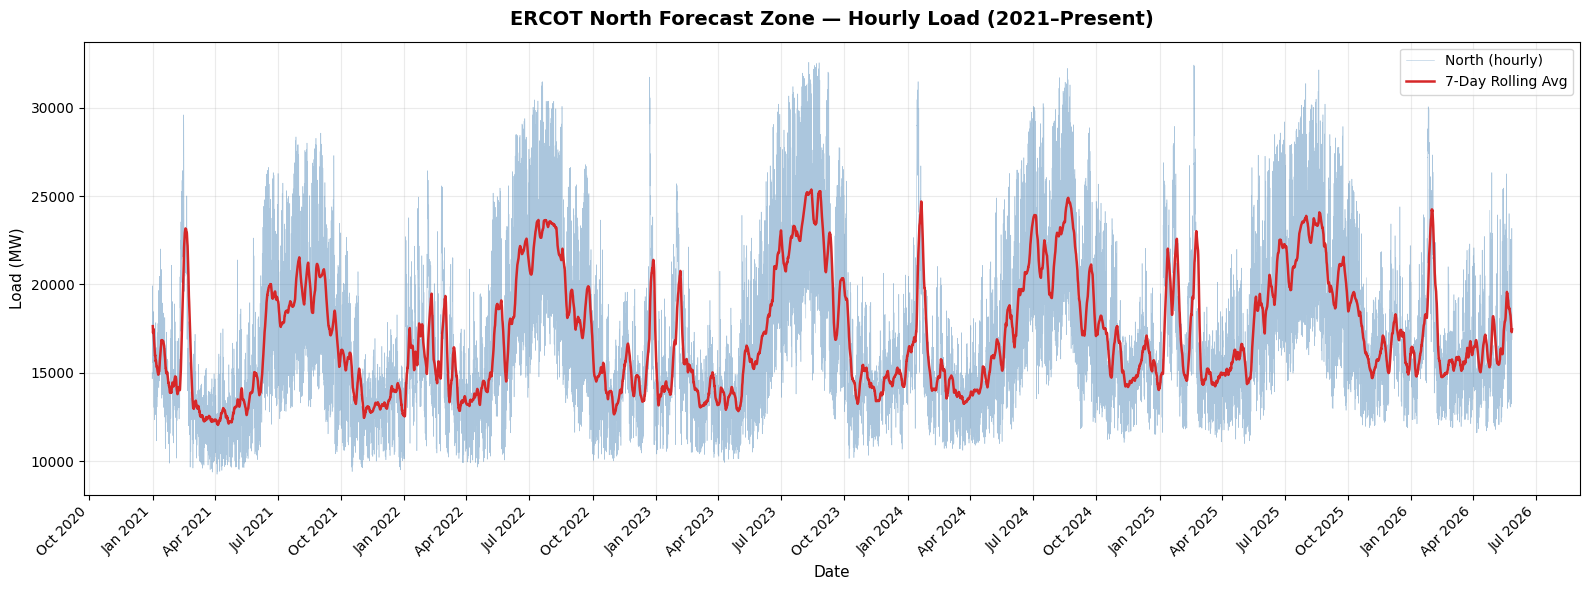

In [36]:
# 7-day rolling average for trend overlay
df['north_7d'] = df['north'].rolling(window=168, min_periods=24).mean()

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(df['datetime'], df['north'],
        color='steelblue', linewidth=0.4, alpha=0.45, label='North (hourly)')
ax.plot(df['datetime'], df['north_7d'],
        color='#d62728', linewidth=1.8, label='7-Day Rolling Avg')

ax.set_title('ERCOT North Forecast Zone — Hourly Load (2021–Present)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Load (MW)', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.25)

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right')

fig.tight_layout()
out_path = Path("../../01_data/3_analysis/output") / 'ercot_load_north_timeseries.png'
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.show()

## 5. Save processed time series

In [42]:
out_parquet = OUT_DIR / 'load_by_LZ_20201231_20260526.parquet'
df.to_parquet(out_parquet, index=False)

In [43]:
aggregated = df.copy()
aggregated.rename(columns={'total': 'total_load'}, inplace=True)
aggregated = aggregated.filter(['datetime', 'total_load'])
aggregated.to_csv(OUT_DIR / 'total_load_20201231_20260526.csv', index=False)
aggregated

,datetime,total_load
0,2020-12-31 01:00:00,39174.39
1,2020-12-31 02:00:00,38284.84
2,2020-12-31 03:00:00,37776.69
3,2020-12-31 04:00:00,37781.84
4,2020-12-31 05:00:00,38455.69
...,...,...
47314,2026-05-26 20:00:00,66009.13
47315,2026-05-26 21:00:00,63250.91
47316,2026-05-26 22:00:00,60728.67
47317,2026-05-26 23:00:00,56995.91
